In [7]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import os
import cv2

In [ ]:
dataset_train = []
dataset_valid = []

for root, dirs, filenames in os.walk('sleeping_face'):
    for filename in filenames:
        image = cv2.imread(root + '/' + filename)
        image = cv2.resize(image, (224, 224))               # cv2는 이미지를 H W C 순서로 
        image = torch.tensor(image).float() / 255           # pyTorch는     C H W 순으로 원함
        image = image.permute(2, 0, 1)
    
        y = torch.tensor(filename[0] == 's').float().reshape(1)
        
        if 'train' in root:
            dataset_train.append( (image, y) )
        else:
            dataset_valid.append( (image, y) )

len(dataset_train), len(dataset_valid)

(178, 33)

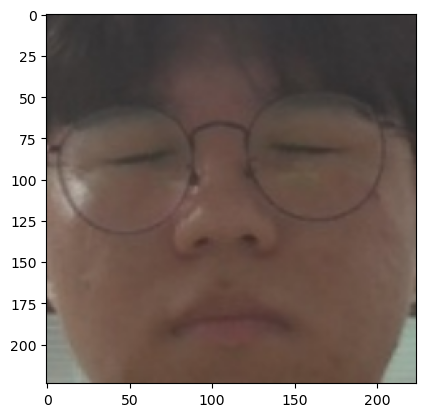

In [19]:
plt.imshow(dataset_valid[0][0].numpy().transpose(1,2,0)[..., [2, 1, 0]])

In [30]:
loader_train = torch.utils.data.DataLoader(dataset_train, batch_size=16, shuffle=True)
loader_valid = torch.utils.data.DataLoader(dataset_valid, batch_size=16)

for x, y in loader_train:
    break
x.shape, y.shape, x.dtype, y.dtype

(torch.Size([16, 3, 224, 224]),
 torch.Size([16, 1]),
 torch.float32,
 torch.float32)

In [31]:
#-- model
# 224 - 112 - 56 -  28 -  14 - 7 - gap - lin - 1
# 32    64    128   256  512 - 1024

def Conv(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size = 3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU()
    )

model = nn.Sequential(
    # 224
    Conv(3, 32),
    Conv(32, 32),
    Conv(32, 32),
    nn.MaxPool2d(2),
    # 112
    Conv(32, 64),
    Conv(64, 64),
    Conv(64, 64),
    nn.MaxPool2d(2),
    # 56
    Conv(64, 128),
    Conv(128, 128),
    Conv(128, 128),
    nn.MaxPool2d(2),
    # 28
    Conv(128, 256),
    Conv(256, 256),
    Conv(256, 256),
    nn.MaxPool2d(2),
    # 14
    Conv(256, 256),
    # 7
    Conv(256, 256),
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(256, 1),
    nn.Sigmoid()
)

model.cuda()

prob =model(x.cuda())
loss_fn = nn.BCELoss()
loss = loss_fn(prob, y.cuda() * 0.8 + 0.1)
loss.backward()

opt = torch.optim.Adam(model.parameters())

In [32]:
# 학습

for epoch in range(100):
    total_loss = 0
    total_acc = 0
    model.train()
    
    for step, (x, y) in enumerate(loader_train):
    # feed - forward loss gead update
        prob = model(x.cuda())
        loss = loss_fn(prob, y.cuda())
        opt.zero_grad()
        loss.backward()
        opt.step()

        #metrics
        total_loss += loss.item()
        acc = ((prob.cpu() > 0.5).float() == y).float().mean()
        total_acc += acc.item()
        
        print('\r epoch = %d step = %d loss = %.4f acc = %.4f' %
              (epoch, step, total_loss / (step+1), total_acc / (step+1)), end='')
    print()
    
    
    # validation
    total_loss = 0
    total_acc = 0
    model.eval()
    
    with torch.no_grad():
        for step, (x, y) in enumerate(loader_valid):
            prob = model(x.cuda())
            loss = loss_fn(prob, y.cuda())
        

            #metrics
            total_loss += loss.item()
            acc = ((prob.cpu() > 0.5).float() == y).float().mean()
            total_acc += acc.item()
            
            print('\r                                                   epoch = %d step = %d loss = %.4f acc = %.4f' %
                (epoch, step, total_loss / (step+1), total_acc / (step+1)), end='')
    print()
    

 epoch = 0 step = 11 loss = 0.7667 acc = 0.5052
                                                   epoch = 0 step = 2 loss = 0.6994 acc = 0.6250
 epoch = 1 step = 11 loss = 0.6984 acc = 0.5104
                                                   epoch = 1 step = 2 loss = 0.7066 acc = 0.3542
 epoch = 2 step = 11 loss = 0.6935 acc = 0.5312
                                                   epoch = 2 step = 2 loss = 0.7242 acc = 0.3542
 epoch = 3 step = 11 loss = 0.6823 acc = 0.5781
                                                   epoch = 3 step = 2 loss = 0.6915 acc = 0.6667
 epoch = 4 step = 11 loss = 0.6895 acc = 0.5365
                                                   epoch = 4 step = 2 loss = 0.6785 acc = 0.6250
 epoch = 5 step = 11 loss = 0.6823 acc = 0.5365
                                                   epoch = 5 step = 2 loss = 0.6818 acc = 0.6250
 epoch = 6 step = 11 loss = 0.6762 acc = 0.5625
                                                   epoch = 6 step = 2 loss = 0.702

In [33]:
torch.save(model.state_dict(), 'model.pt')